# Projet : Détection de fraude bancaire

Hadoop, HDFS sur `localhost:9000`
PaySim (transactions mobile money synthétiques & anonymisés, ~6,3M lignes)
Random Forest 


1. Importation depuis HDFS
2. Parsing
3. Nettoyage / feature engineering
4. Statistiques descriptives
5. Machine Learning
6. Data Viz

> (`start-dfs.sh` + `start-yarn.sh`).
> csv dans HDFS : `hdfs://localhost:9000/data/raw/fraud.csv`

In [10]:
MODE_TEST = False   # True = petite partie du csv, sinon tout
TAILLE_ECHANTILLON = 0.05   # 5%

## Démarrage de Spark

In [11]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("DetectionFraude") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark version :", spark.version)

Spark version : 4.1.2


## 1. Importation dataset depuis HDFS

In [12]:
CHEMIN_HDFS = "hdfs://localhost:9000/data/raw/fraud.csv"

df = spark.read.csv(CHEMIN_HDFS, header=True, inferSchema=True)

if MODE_TEST:
    df = df.sample(fraction=TAILLE_ECHANTILLON, seed=42)
    print(f"voici {TAILLE_ECHANTILLON*100:.0f}% des donnees")
else:
    print("tout car pas mode test")

[Stage 13:>                                                         (0 + 8) / 8]

tout car pas mode test


## 2. Parsing 

In [13]:
print("apercu :")
df.show(5)

apercu :
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|           0.0|      0|             0|
|   1| PAYMENT| 1864.28|C1666544295|      21249.0|      19384.72|M2044282225|           0.0|           0.0|      0|             0|
|   1|TRANSFER|   181.0|C1305486145|        181.0|           0.0| C553264065|           0.0|           0.0|      1|             0|
|   1|CASH_OUT|   181.0| C840083671|        181.0|           0.0|  C38997010|       21182.0|           0.0|      1|             0|
|   1| PAYMENT|11668.14|C2048537720|      41554.0|      29885.86|M12307017

In [14]:
print("colonnes & types :")
df.printSchema()

colonnes & types :
root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- isFlaggedFraud: integer (nullable = true)



In [15]:
print("nb lignes traitees:", df.count())

nb lignes traitees: 6362620


## 3. Nettoyage et feature engineering

In [16]:
# doublons
df = df.dropDuplicates()

In [17]:
#on garde que la premiere lettre et pas les chiffres derriere "typeEchange"
# C = Client (particulier), M = Merchant (commercant)
#donc "CC" = particulier -> particulier
df = df.withColumn(
    "typeEchange",
    F.concat(F.substring("nameOrig", 1, 1), F.substring("nameDest", 1, 1))
)

In [18]:
# verif isFlaggedFraud (systeme reperage de fraudes)
#donc on avec la realite (isFraud), pour voir s'il fonctionne
print("isFlaggedFraud comparé à la vraie fraude :")
df.groupBy("isFraud", "isFlaggedFraud").count().orderBy("isFraud", "isFlaggedFraud").show()

isFlaggedFraud comparé à la vraie fraude :


[Stage 20:>                                                         (0 + 8) / 9]

+-------+--------------+-------+
|isFraud|isFlaggedFraud|  count|
+-------+--------------+-------+
|      0|             0|6354407|
|      1|             0|   8197|
|      1|             1|     16|
+-------+--------------+-------+



In [19]:
#on vire colonnes inutiles : 
# id de compte
#  isFlaggedFraud (l'ancien systeme naif)
df = df.select(
    "step", "type", "amount",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "typeEchange", "isFraud"
)

In [20]:
# pas besoin des lignes si la colonne qui nous interesse est vide 
df = df.dropna(subset=["isFraud"])

## 4. Statistiques

In [23]:
print("fraude/non-fraude :")
df.groupBy("isFraud").count().show()

fraude/non-fraude :


[Stage 32:>                                                         (0 + 8) / 9]

+-------+-------+
|isFraud|  count|
+-------+-------+
|      1|   8213|
|      0|6354407|
+-------+-------+



In [24]:
print("fraude/type transaction :")
df.groupBy("type", "isFraud").count().orderBy("type").show()

fraude/type transaction :


[Stage 38:>                                                         (0 + 8) / 9]

+--------+-------+-------+
|    type|isFraud|  count|
+--------+-------+-------+
| CASH_IN|      0|1399284|
|CASH_OUT|      0|2233384|
|CASH_OUT|      1|   4116|
|   DEBIT|      0|  41432|
| PAYMENT|      0|2151495|
|TRANSFER|      1|   4097|
|TRANSFER|      0| 528812|
+--------+-------+-------+



In [26]:
print("fraude/type d'echange (CC,CM...) :")
df.groupBy("typeEchange", "isFraud").count().orderBy("typeEchange").show()

fraude/type d'echange (CC,CM...) :


[Stage 50:>                                                         (0 + 8) / 9]

+-----------+-------+-------+
|typeEchange|isFraud|  count|
+-----------+-------+-------+
|         CC|      0|4202912|
|         CC|      1|   8213|
|         CM|      0|2151495|
+-----------+-------+-------+



In [27]:
print("stat montant :")
df.select("amount").describe().show()

stat montant :


[Stage 56:======>                                                   (1 + 8) / 9]

+-------+------------------+
|summary|            amount|
+-------+------------------+
|  count|           6362620|
|   mean|179861.90354913106|
| stddev| 603858.2314629356|
|    min|               0.0|
|    max|     9.244551664E7|
+-------+------------------+



## 5. Machine Learning : Random Forest

MLlib a beosin variables **numériques** et rassemblées dans colonne features
- **StringIndexer** : texte ("PAYMENT", "CC"...) → nombres
- **VectorAssembler** : rassemble colonnes → 1 vecteur
- **RandomForestClassifier** :modèle (arbres qui votent)

In [28]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

In [29]:
#colonnes txt → nb
indexeur_type = StringIndexer(inputCol="type", outputCol="type_num")
indexeur_echange = StringIndexer(inputCol="typeEchange", outputCol="typeEchange_num")

In [30]:
# pour predic
colonnes_features = [
    "step", "type_num", "amount",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "typeEchange_num"
]
assembleur = VectorAssembler(inputCols=colonnes_features, outputCol="features")

In [31]:
#50 ab decision
modele_rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="isFraud",
    numTrees=50
)

In [32]:

pipeline = Pipeline(stages=[indexeur_type, indexeur_echange, assembleur, modele_rf])

In [33]:
#sep 80/20
train, test = df.randomSplit([0.8, 0.2], seed=42)

In [34]:
modele = pipeline.fit(train)

26/07/01 11:14:54 WARN MemoryStore: Not enough space to cache rdd_194_5 in memory! (computed 40.7 MiB so far)
26/07/01 11:14:54 WARN BlockManager: Persisting block rdd_194_5 to disk instead.
26/07/01 11:14:54 WARN MemoryStore: Not enough space to cache rdd_194_0 in memory! (computed 40.7 MiB so far)
26/07/01 11:14:54 WARN BlockManager: Persisting block rdd_194_0 to disk instead.
26/07/01 11:14:54 WARN MemoryStore: Not enough space to cache rdd_194_4 in memory! (computed 40.7 MiB so far)
26/07/01 11:14:54 WARN BlockManager: Persisting block rdd_194_4 to disk instead.
26/07/01 11:14:54 WARN MemoryStore: Not enough space to cache rdd_194_2 in memory! (computed 40.7 MiB so far)
26/07/01 11:14:54 WARN BlockManager: Persisting block rdd_194_2 to disk instead.
26/07/01 11:14:54 WARN MemoryStore: Not enough space to cache rdd_194_7 in memory! (computed 40.7 MiB so far)
26/07/01 11:14:54 WARN BlockManager: Persisting block rdd_194_7 to disk instead.
26/07/01 11:14:54 WARN MemoryStore: Not enoug

In [35]:
predictions = modele.transform(test)
print("ex predictions:")
predictions.select("isFraud", "prediction", "probability").show(10)

ex predictions:


[Stage 114:>                                                        (0 + 1) / 1]

+-------+----------+--------------------+
|isFraud|prediction|         probability|
+-------+----------+--------------------+
|      0|       0.0|[0.99969054732158...|
|      0|       0.0|[0.99967732204547...|
|      0|       0.0|[0.99967078248472...|
|      0|       0.0|[0.99967732204547...|
|      0|       0.0|[0.99963216159710...|
|      0|       0.0|[0.99969051284100...|
|      0|       0.0|[0.99967081696530...|
|      0|       0.0|[0.99962562203635...|
|      0|       0.0|[0.99963216159710...|
|      0|       0.0|[0.99967732204547...|
+-------+----------+--------------------+
only showing top 10 rows


## 5bis. Évaluation modèle

In [36]:
# AUC = 1.0 = parfait, 0.5 = hasard)
evaluateur_auc = BinaryClassificationEvaluator(
    labelCol="isFraud", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)
print("AUC :", round(evaluateur_auc.evaluate(predictions), 4))

[Stage 117:======================================>                  (6 + 3) / 9]

AUC : 0.9833


In [37]:
#dataset edsiquilibre donc : Precision, recall, F1
for metrique in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    ev = MulticlassClassificationEvaluator(
        labelCol="isFraud", predictionCol="prediction", metricName=metrique
    )
    print(metrique, ":", round(ev.evaluate(predictions), 4))

accuracy : 0.9993


weightedPrecision : 0.9993


weightedRecall : 0.9993


[Stage 145:============================================>            (7 + 2) / 9]

f1 : 0.9992


In [38]:
# matrice confusion
print("Matrice confusion(isFraud reel vs prediction) :")
predictions.groupBy("isFraud", "prediction").count().orderBy("isFraud", "prediction").show()

Matrice confusion(isFraud reel vs prediction) :


[Stage 149:=========================>                               (4 + 5) / 9]

+-------+----------+-------+
|isFraud|prediction|  count|
+-------+----------+-------+
|      0|       0.0|1271244|
|      0|       1.0|      2|
|      1|       0.0|    869|
|      1|       1.0|    817|
+-------+----------+-------+



## 6. Data Visualisation

RF =  montre colonnes plus utile 

In [39]:
rf_entraine = modele.stages[-1]
importances = rf_entraine.featureImportances

print("Importance / variable :")
for nom, score in zip(colonnes_features, importances):
    print(f"  {nom:20s} : {round(float(score), 4)}")

Importance / variable :
  step                 : 0.0232
  type_num             : 0.1144
  amount               : 0.0448
  oldbalanceOrg        : 0.3519
  newbalanceOrig       : 0.0588
  oldbalanceDest       : 0.0718
  newbalanceDest       : 0.3344
  typeEchange_num      : 0.0007


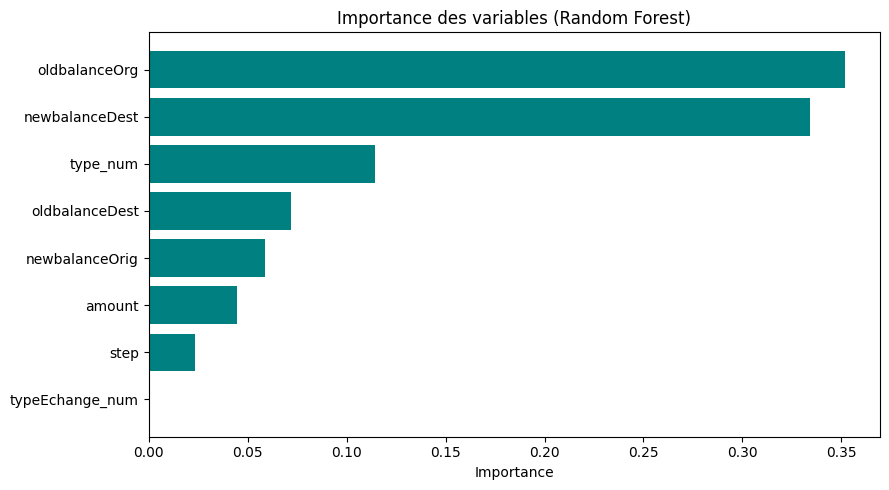

In [40]:
import matplotlib.pyplot as plt

scores = [float(importances[i]) for i in range(len(colonnes_features))]
paires = sorted(zip(colonnes_features, scores), key=lambda x: x[1])
noms = [p[0] for p in paires]
vals = [p[1] for p in paires]

plt.figure(figsize=(9, 5))
plt.barh(noms, vals, color="teal")
plt.title("Importance des variables (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7.Sauvegarder un échantillon dans HDFS

Crée un petit échantillon réutilisable dans `/data/samples/` pour les tests
futurs, sans repasser par le fichier complet.

In [41]:
# enlever # pour generer echatillon  
# echantillon = spark.read.csv(CHEMIN_HDFS, header=True, inferSchema=True).sample(0.05, seed=42)
# echantillon.write.csv("hdfs://localhost:9000/data/samples/paysim_sample", header=True, mode="overwrite")
# print("Echantillon dans /data/samples/")

## Fin :liberer ressources

In [42]:
spark.stop()